#  Taxi order forecasting

The Clear Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak periods, you need to predict the number of taxi orders for the next hour. Build a model to make this prediction.

The *RMSE* metric value on the test sample should be no more than 48.

You need:

1. Load the data and resample it one hour at a time.
2. Analyze the data.
3. Train different models with different hyperparameters. Make a test sample of 10% of the original data.
4. Check the data on a test sample and draw conclusions.


The data is in the file `taxi.csv`. The number of orders is in the `num_orders` column (from the English *number of orders*, “number of orders”).

## Preparation

In [1]:
# import the necessary libraries and modules
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# read the file, take the date as an index
taxi = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

In [3]:

# print the first 5 lines
taxi.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [4]:
# sort the index in ascending order
taxi.sort_index(inplace=True)

In [5]:
# we will resample for 1 hour
taxi = taxi.resample('1H').sum()

In [6]:
taxi.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [7]:
# check the chronological order
taxi.index.is_monotonic

True

In [8]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


**Conclusion:** data was successfully resampled for 1 hour, the chronological order was preserved

## Analysis

In [9]:
# count the number of duplicates
taxi.isna().sum()

num_orders    0
dtype: int64

In [10]:
# check for duplicates among indexes
taxi.index.duplicated().sum()

0

In [11]:
min(taxi.index)

Timestamp('2018-03-01 00:00:00', freq='H')

In [12]:
max(taxi.index)

Timestamp('2018-08-31 23:00:00', freq='H')

The table presents data for 6 months: from March to August 2018

In [13]:
# let's create a function to design a graph
def plot_series(series, title):
    ax = series.plot()
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of orders')
    plt.show()

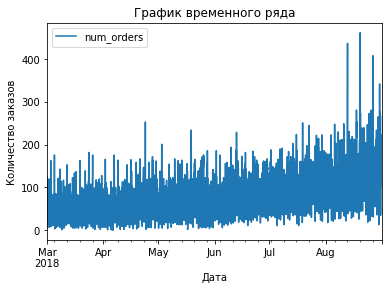

In [14]:
# let's build a time series graph
plot_series(taxi, 'Time series graph')

This graph is not very informative, but you can see a strong increase in orders in mid-to-late August, you need to take a closer look at this

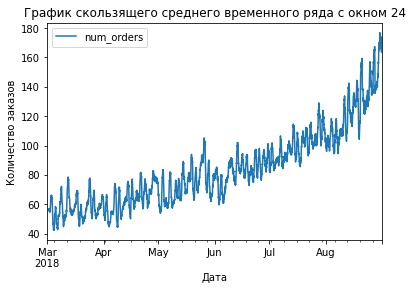

In [15]:
# smooth the graph using a moving average, take a window of 24 hours - 1 day
plot_series(taxi.rolling(24).mean(), 'Moving average chart of a time series with a window of 24')

The smoothed graph still shows an increase in August

In [16]:
# Let's decompose the time series into 3 components: trend, seasonality, residuals with a weekly frequency
weekly_decomposed = seasonal_decompose(taxi, period=168)

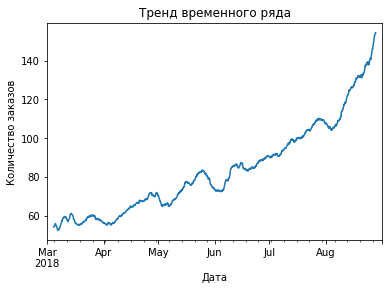

In [17]:
plot_series(weekly_decomposed.trend, 'Time series trend')

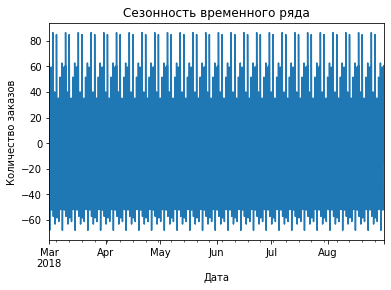

In [18]:
plot_series(weekly_decomposed.seasonal, 'Seasonality of time series')

Let's look at seasonality within 1 week, first we need to find out on what day of the week the data starts

In [19]:
pd.Timestamp('2018-03-01').day_name()

'Thursday'

March 1, 2018 is Thursday, which means Monday will be March 5, 2018, consider the slice from 96 hours to 264 hours

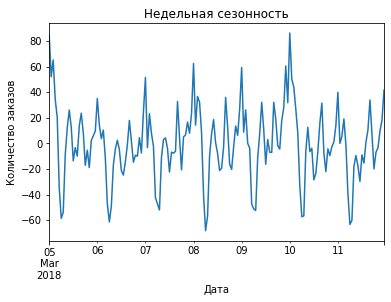

In [20]:
# Let's look at the seasonality within the week
plot_series(weekly_decomposed.seasonal.iloc[96:264], 'Weekly seasonality')

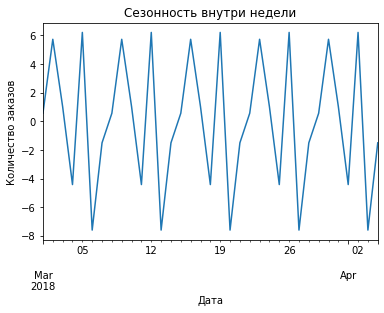

In [21]:
daily = taxi.resample('D').mean()
decomp = seasonal_decompose(daily)
plot_series(decomp.seasonal.iloc[:35], 'Seasonality within a week')

The time series trend with a period of a week shows an increase in orders from March to August, and the increase is non-linear and begins to grow more actively in June-July, this may be due to the fact that the holiday season begins in the summer and taxis at the airport are in great demand. 
At the beginning of each week, especially on Monday, there are sharp peaks in the number of orders, reaching +60-85 orders above average. During weekdays, demand remains at a positive or moderate level, then begins to decline towards the end of the week. By Sunday, the number of orders drops to minimum values, falling 50-65 orders below average, which creates characteristic deep dips in the chart.

The highest peak occurs on March 10 (Friday) and exceeds 80 orders. The amplitude of fluctuations between highs and lows is about 140 orders, which indicates a strong dependence of demand on the day of the week.

In [22]:
daily_decomposed = seasonal_decompose(taxi, period=24)

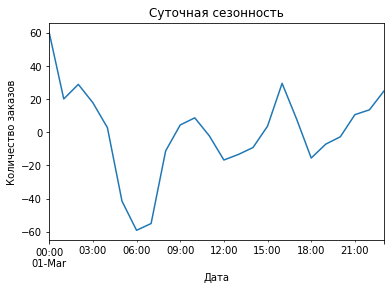

In [23]:
plot_series(daily_decomposed.seasonal[:24], 'Daily seasonality')

At midnight, a sharp peak of about +60 orders is visible, which is associated with the arrival of late evening and night international flights - passengers receive luggage and en masse order a taxi home or to hotels.

From 3 to 6 am there is a drop of up to -60 orders. This is the “deadest” time at the airport, when there are practically no flights due to curfews and low demand, therefore there are no passengers and almost no orders are received.

After 6 a.m., recovery begins due to morning arrivals of business and domestic flights. By 9-11 o'clock demand reaches positive values, followed by a daily decline during the transit period. The most noticeable evening peak occurs at 18:00 with a rise of up to +30 orders - this is a massive arrival of popular evening flights, when people return from work or business trips. After a slight dip around 20:00, demand increases again towards the end of the day.

**Conclusion:** The data in the dataframe is presented for 6 months - from March to August 2018. There are no gaps or duplicates in the data. 
*Trend:* Non-linear growth of orders from March to August with acceleration in June-July (holiday season and increased traffic at the airport).

*Weekly seasonality:* Strong dependence on the day of the week with an amplitude of ~140 orders. Peaks at the beginning of the week (Monday: +60-85 orders), decline towards the weekend, minimum on Sunday (-50-65 orders). The maximum peak is March 10 (+80 orders).

*Daily seasonality:*
- Midnight: sharp peak (+60) - arrival of late international flights
- 3-6 am: dip (-60) - no flights
- 18:00: evening peak (+30) - mass arrivals of popular flights
- Moderate demand 9-11 hours (morning arrivals)

Key factor: Demand is tightly tied to flight schedules and day of the week.

## Training

### Data preparation

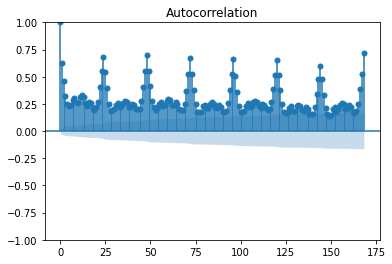

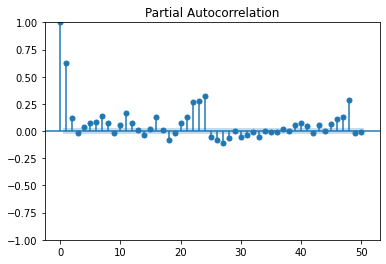

In [24]:
# let's build an autocorrelation graph
plot_acf(taxi['num_orders'], lags=168);
plot_pacf(taxi['num_orders'], lags=50, method='ywm');

In [25]:
# let's create a function to create new features
def make_features(data):
    data['dayofweek'] = data.index.dayofweek # the number of orders depends on the day of the week
    data['hour'] = data.index.hour
    for lag in [1, 2, 24]:
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(24).mean() 

In [26]:
make_features(taxi)

In [27]:
taxi.head()

,num_orders,dayofweek,hour,lag_1,lag_2,lag_24,rolling_mean
datetime,,,,,,,
2018-03-01 00:00:00,124,3,0,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,124.0,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,2,85.0,124.0,NaN,NaN
2018-03-01 03:00:00,66,3,3,71.0,85.0,NaN,NaN
2018-03-01 04:00:00,43,3,4,66.0,71.0,NaN,NaN


Let's divide the data into training, validation and test samples

In [28]:
train, test = train_test_split(taxi, shuffle=False, test_size=0.1)

Let's check the data partitioning

In [29]:
train.index.min(), train.index.max()

(Timestamp('2018-03-01 00:00:00', freq='H'),
 Timestamp('2018-08-13 13:00:00', freq='H'))

In [30]:
test.index.min(), test.index.max()

(Timestamp('2018-08-13 14:00:00', freq='H'),
 Timestamp('2018-08-31 23:00:00', freq='H'))

Data is split correctly

In [31]:
# remove gaps in the training set
train = train.dropna()

In [32]:
X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

In [33]:
X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

In [34]:
tscv = TimeSeriesSplit(n_splits=3) 

### Model training

In [35]:
def get_rmse(model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_train)
    rmse = mean_squared_error(y_train, predictions, squared=False)
    return [rmse, model]

In [36]:
def get_rmse_cv(model):
    tscv = TimeSeriesSplit(n_splits=5)
    rmse_scores = []

    for train_idx, val_idx in tscv.split(train):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        predictions = model.predict(X_val_fold)
        rmse = mean_squared_error(y_val_fold, predictions, squared=False)
        rmse_scores.append(rmse)

    return [np.mean(rmse_scores), model]

In [37]:
results = {}

In [38]:
# add the result of linear regression
results['LinearRegression'] = get_rmse(LinearRegression())

In [39]:
# add the result of the decision tree
results['DecisionTreeRegressor'] = get_rmse(GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=12345), 
    cv=tscv, 
    param_grid={'max_depth':range(1,11,2)}))

In [40]:
results['CatBoostRegressor'] = get_rmse(GridSearchCV(
            estimator=CatBoostRegressor(verbose=0, allow_writing_files=False),
            cv=tscv,
            param_grid={
    'iterations': [200],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6]
},
    n_jobs=1
))

In [ ]:
results['LGBMRegressor'] = get_rmse(RandomizedSearchCV(
    estimator=LGBMRegressor(
        verbose=-1,
        force_col_wise=True,
        min_child_samples=1,
        min_split_gain=0.0
    ),
    cv=tscv,
    param_distributions={
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [4, 6],
        'num_leaves': [31, 50]
    
    },
    n_iter=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
))

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
# display the training result
pd.DataFrame(results, index=['rmse', 'model']).T

During model training, new features were created using the make_features function, and the data was divided into training and test sets. The following models were trained: LinearRegression, DecisionTreeRegressor, CatBoostRegressor, LGBMRegressor. The best metric was shown by the LGBMRegressor model, it is worth choosing for testing

## Testing

In [ ]:
# let's pass the best model to a variable
best_model = results['LGBMRegressor'][1]

In [ ]:
best_model

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
# Let's check the metric on a test sample
mean_squared_error(y_test, y_pred, squared=False)

The metric satisfies the conditions of the problem; let’s check the model for adequacy in two ways: by predicting a constant and by the previous value of the series

In [ ]:
pred_median = np.ones(y_test.shape) * train['num_orders'].median()

In [ ]:
mean_squared_error(y_test, pred_median, squared=False)

In [ ]:
pred_previous = test['num_orders'].shift()
pred_previous.iloc[0] = train['num_orders'].iloc[-1]

In [ ]:
mean_squared_error(y_test, pred_previous, squared=False)

The model showed a better metric compared to the forecast of the median and the previous value, which means its use is advisable

## Conclusion:

The problem was solved - the model turned out to be working and meets the requirements. The RMSE on the test set is 44, which is less than the threshold value of 48.

 What emerged from the analysis:

The data showed clear patterns:
- There are more orders in the summer (apparently, the holiday season), the growth starts in March and accelerates by August
- There is also an interesting picture for the days of the week: on Monday everyone goes (+60-85 orders), and by Sunday everything calms down (falls by -50-65)
- During the day: peak at midnight at night (night flights arrive), then dead hour from 3 to 6 am, calm during the day, rise again in the evening at 18:00

 How I trained the models:

I tried 4 different options - linear regression, decision tree, CatBoost and LGBMRegressor.

LGBMRegressor showed itself to be the best - on validation the RMSE was generally 14, on test it was 44.

 Adequacy check:

Compared with simple methods:
- If you just predict the median - RMSE = 87
- If we take the previous value - RMSE = 59

My model beats both of these with a score of 46, so it actually predicts something useful rather than just repeating the data.

Conclusion: The LGBMRegressor model can be used to forecast orders, it takes into account all patterns and works better than basic approaches.